In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


data = pd.read_csv('diamonds.csv')
print("Details about data")
print(data.info())

Details about data
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 5.1 MB
None


In [2]:
#filter out invalid entries where dimensional measurements equal zero
data = data[data['x'] != 0]
data = data[data['y'] != 0]
data = data[data['z'] != 0]

In [20]:
#identify non numeric columns
# s = (data.dtypes == 'object')
# print(s)
# object_cols = list(s[s].index)
# print(object_cols)
# s = (data.dtypes == 'object') | (data.dtypes == 'category')
# print(s)
# object_cols = list(s[s].index)
# print(object_cols)
object_cols = list(data.select_dtypes(include=['object']).columns)
print("Categorical columns to encode:", object_cols)
#convert text labels into numerical values
lb = LabelEncoder()
for c in object_cols:
    data[c] = lb.fit_transform(data[c].astype(str)) #to prevent type mismatches

Categorical columns to encode: ['cut', 'color', 'clarity']


C:\Users\Admin\AppData\Local\Temp\ipykernel_11028\4077370064.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = list(data.select_dtypes(include=['object']).columns)


In [21]:
#split feature and target variable

#isolate feature matrix X and target array Y
X = data.drop(['price'], axis=1)
Y = data['price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=75)

In [22]:
#train linear regression model and generate predictions
lr = LinearRegression()
lr.fit(X_train, Y_train)
#evaluate predictions 
pred_test = lr.predict(X_test)
pred_train = lr.predict(X_train)


MSE = 1790220.1412644135
MAE = 861.8693793722666


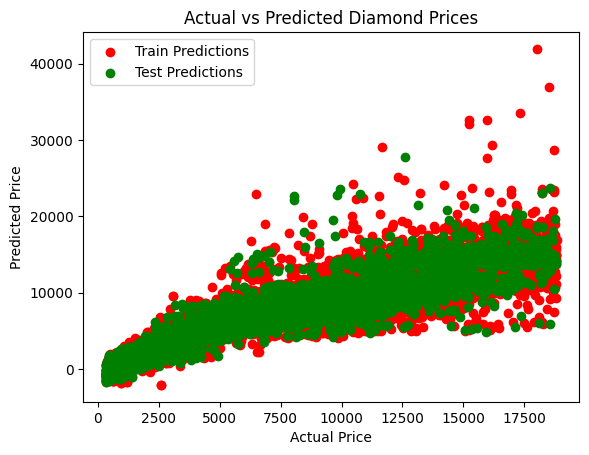

In [23]:
print("MSE =", mean_squared_error(Y_test, pred_test))
print("MAE =", mean_absolute_error(Y_test, pred_test))

plt.scatter(Y_train, pred_train, color='red', label='Train Predictions')
plt.scatter(Y_test, pred_test, color='green', label='Test Predictions')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Diamond Prices")
plt.show()